# CC_Plot_strip_IS_member67

Task 1 (updated): Ice sheet presence for **member 67 only** (index 66), site LA.
Left: stacked area (0–100%) per scenario. Right: pie chart of time fractions.
Colors: `steelblue` = ice present, `mediumseagreen` = no ice.

Generated by Claude Code (CC_ prefix rule).
Source notebook: `Plot_strip_IS.ipynb`
Backup: `CC_Plot_strip_IS_member67_backup_20260528.ipynb`

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [36]:
# ── Configuration ────────────────────────────────────────────────────────────
variables  = ["temp", "precip", "evap", "soiltemp", "sm",
              "snowdepth", "LAI_PFT", "windspeed", "iceconc", "ice_sheet"]
var        = 9          # ice_sheet
site       = "_LA"
member_idx = 66         # member 67 (0-indexed)
ice_thresh = 1.0        # values >= threshold → ice present

scenarios   = ["natural", "SSP126", "SSP245", "SSP370", "SSP585", "10000PGC"]
scen_labels = ["Natural", "SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5", "10,000 PgC"]

COLOR_ICE   = 'steelblue'   # 正常蓝
COLOR_NOICE = 'white'       # no ice = white

data_path = ("/Users/bo20541/Library/CloudStorage/"
             "OneDrive-UniversityofBristol/NWS-PDRA/NWS_emulation/"
             "prediction/results_on_sites/low_reso_sites/")
out_path  = "plots/ice_sheet_site_LA_stackplot_with_pie_67.png"

In [37]:
# ── Load data for member 67 ──────────────────────────────────────────────────
member_data = {}   # {scen_idx: 1-D boolean array, length = n_timesteps}

for scen_idx, scen in enumerate(scenarios):
    fpath = f"{data_path}site{site}/{variables[var]}_{scen}_site{site}.txt"
    print(f"Loading: {fpath}")
    data = np.loadtxt(fpath)          # shape (90, n_timesteps)
    print(f"  shape: {data.shape}")
    member_data[scen_idx] = data[member_idx, :] >= ice_thresh  # True = ice present

Loading: /Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/NWS-PDRA/NWS_emulation/prediction/results_on_sites/low_reso_sites/site_LA/ice_sheet_natural_site_LA.txt
  shape: (90, 1001)
Loading: /Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/NWS-PDRA/NWS_emulation/prediction/results_on_sites/low_reso_sites/site_LA/ice_sheet_SSP126_site_LA.txt
  shape: (90, 1001)
Loading: /Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/NWS-PDRA/NWS_emulation/prediction/results_on_sites/low_reso_sites/site_LA/ice_sheet_SSP245_site_LA.txt
  shape: (90, 1001)
Loading: /Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/NWS-PDRA/NWS_emulation/prediction/results_on_sites/low_reso_sites/site_LA/ice_sheet_SSP370_site_LA.txt
  shape: (90, 1001)
Loading: /Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/NWS-PDRA/NWS_emulation/prediction/results_on_sites/low_reso_sites/site_LA/ice_sheet_SSP585_site_LA.txt
  shape: (90, 1001)
Loading: /User

In [38]:
# Quick check – fraction of time with ice per scenario
for scen_idx in range(len(scenarios)):
    frac = member_data[scen_idx].mean() * 100
    print(f"{scen_labels[scen_idx]:12s}: {frac:.1f}% of time has ice sheet")

Natural     : 0.0% of time has ice sheet
SSP1-2.6    : 0.0% of time has ice sheet
SSP2-4.5    : 0.0% of time has ice sheet
SSP3-7.0    : 0.1% of time has ice sheet
SSP5-8.5    : 0.0% of time has ice sheet
10,000 PgC  : 0.0% of time has ice sheet


Saved to: plots/ice_sheet_site_LA_stackplot_with_pie_67.png


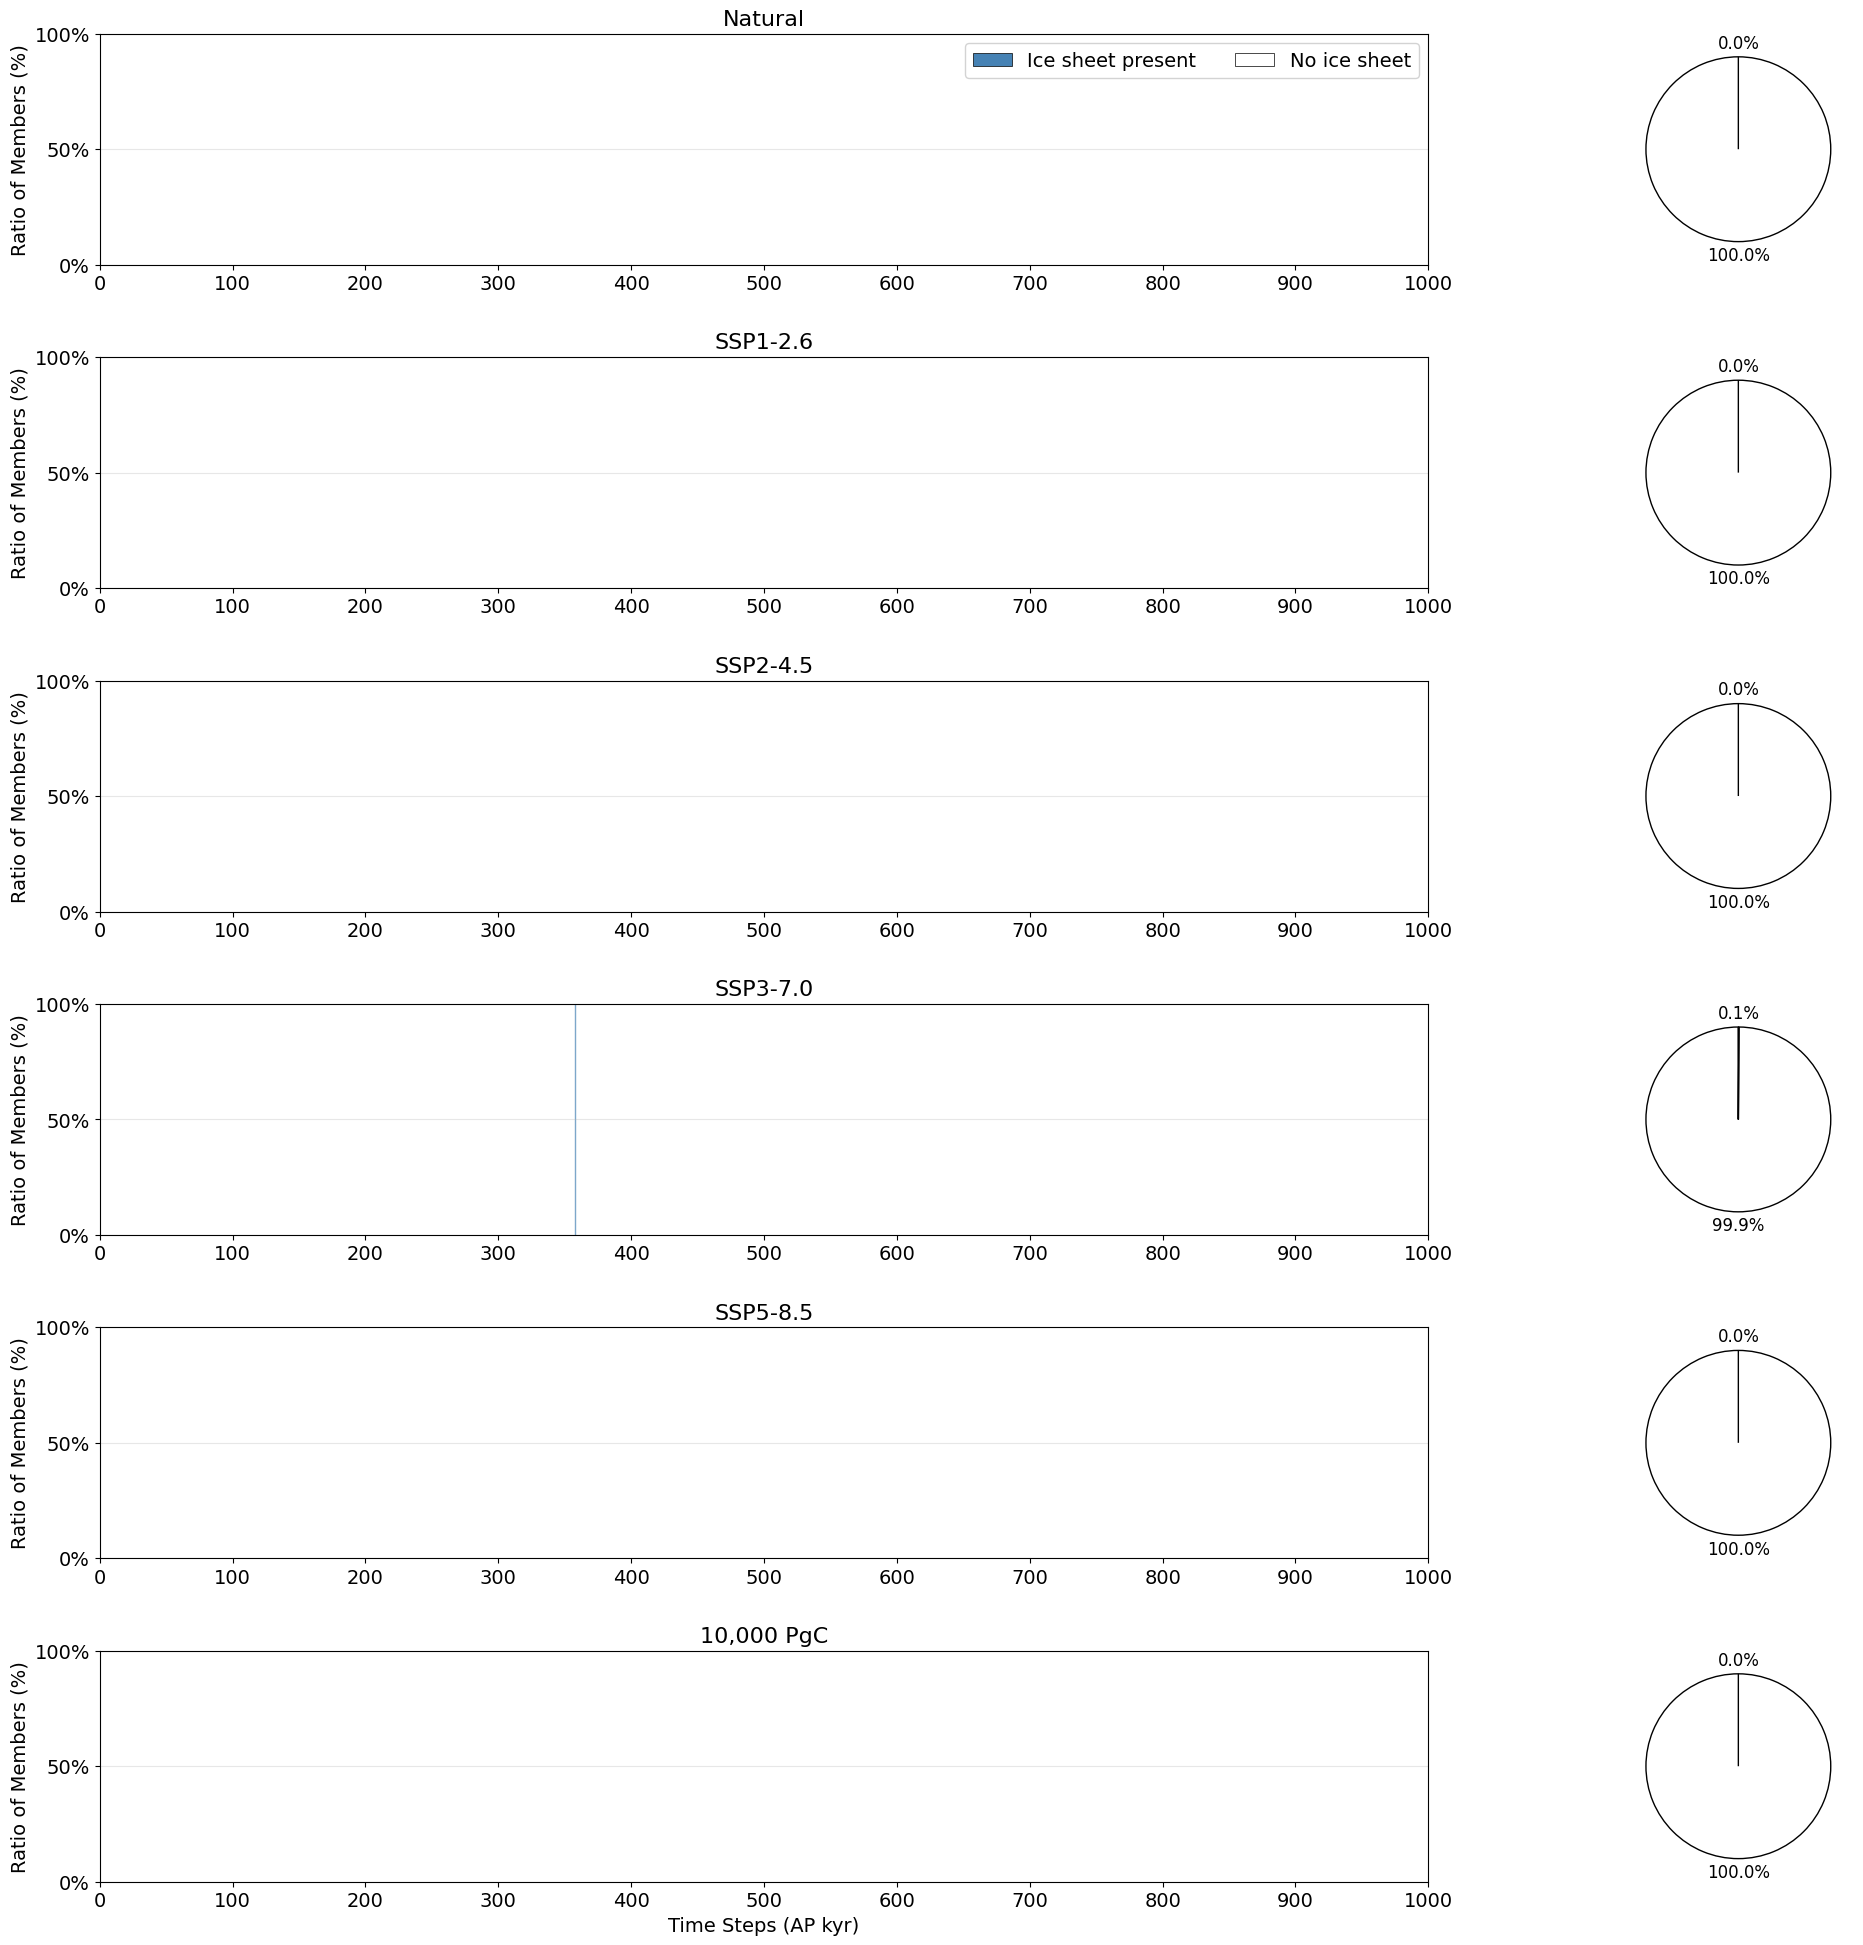

In [39]:
# ── Plot ─────────────────────────────────────────────────────────────────────
n_scen      = len(scenarios)
n_timesteps = member_data[0].shape[0]   # 1001
time_steps  = np.arange(n_timesteps)

fig = plt.figure(figsize=(24, 4 * n_scen))
gs  = GridSpec(n_scen, 2, figure=fig,
               width_ratios=[3, 1], hspace=0.4, wspace=0.1)

for scen_idx, scen_label in enumerate(scen_labels):
    ice = member_data[scen_idx].astype(float)   # 0.0 or 1.0, shape (1001,)

    # ── Left: binary fill ─────────────────────────────────────────────────
    # Use fill_between with step='post' to get sharp vertical edges at each
    # transition — stackplot linearly interpolates between points, which
    # creates diagonal wedge artifacts for binary (0/1) data.
    ax1 = fig.add_subplot(gs[scen_idx, 0])
    ax1.fill_between(time_steps, 0, 100,
                     color=COLOR_NOICE, alpha=0.7, step='post')
    ax1.fill_between(time_steps, 0, 100, where=ice > 0,
                     color=COLOR_ICE, alpha=0.7, step='post')

    ax1.set_xlim(0, 1000)
    ax1.set_xticks(time_steps[::100])
    ax1.set_xticklabels(time_steps[::100], fontsize=14)
    ax1.set_ylim(0, 100)
    ax1.set_yticks([0, 50, 100])
    ax1.set_yticklabels(['0%', '50%', '100%'], fontsize=14)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_ylabel('Ratio of Members (%)', fontsize=14)
    ax1.set_title(scen_label, fontsize=16)
    ax1.grid(axis='y', alpha=0.3)

    if scen_idx == n_scen - 1:
        ax1.set_xlabel('Time Steps (AP kyr)', fontsize=14)

    # Legend on first row only
    if scen_idx == 0:
        handles = [
            mpatches.Patch(facecolor=COLOR_ICE,   edgecolor='black',
                           linewidth=0.5, label='Ice sheet present'),
            mpatches.Patch(facecolor=COLOR_NOICE, edgecolor='black',
                           linewidth=0.5, label='No ice sheet'),
        ]
        ax1.legend(handles=handles, loc='upper right', fontsize=14,
                   framealpha=0.85, ncol=2)

    # ── Right: pie chart ───────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[scen_idx, 1])
    pie_vals = [float((1 - ice).sum()), float(ice.sum())]
    ax2.pie(
        pie_vals,
        colors=[COLOR_NOICE, COLOR_ICE],
        autopct='%1.1f%%',
        pctdistance=1.15,
        startangle=90,
        textprops={'fontsize': 12},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1}
    )

# fig.suptitle('Ice Sheet Presence at Site LA — Member 67',
#              fontsize=14, y=1.01)

plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved to: {out_path}")
plt.show()